In [1]:
# !pip install numpy

# Задание №2. Метод ломаных. Поиск глобального экстремума методом ломаных

Выполнил: Проскуряков Роман Владимирович МЕТОПТ 1.2

В этом ноутбуке реализован алгоритм глобальной минимизации одномерной липшицевой функции методом ломаных.

**Что делает ноутбук**:
- Парсит входное выражение функции (строку), например `f(x) = x + sin(3.14159*x)` или в форме `x + np.sin(3.14159*x)`.
- Оценка константы Липшица `L` делается численным приближением производной на сетке (по умолчанию 200 точек). Это — разумный компромисс (не «перебор по мелкой сетке» для нахождения минимума, а лишь оценка `L`). Если пользователь знает `L`, можно указать явно.
- Реализует алгоритм: строит нижнюю выпуклую огибающую из отрезков вида `f(x_i) - L*|x-x_i|`, находит точку минимума этой огибающей между соседними образцами и берет ее как следующую пробную точку.
- Критерий остановки: `f_best - lower_bound <= eps` (разность между наилучшим найденным значением и текущей нижней оценкой меньше `eps`).
- Визуализация: график исходной функции, точки выборки, нижняя ломаная (огибающая), финальная найденная точка минимума.


In [2]:

# Ячейка: Подготовка (зависимости, парсер выражений и реализация алгоритма)
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# Безопасный парсер: преобразуем математическую строку в выражение для numpy.
# Поддерживаем распространённые функции: sin, cos, tan, exp, log, sqrt, abs, pi, e
_replacements = {
    'sin': 'np.sin',
    'cos': 'np.cos',
    'tan': 'np.tan',
    'exp': 'np.exp',
    'log': 'np.log',
    'sqrt': 'np.sqrt',
    'abs': 'np.abs',
    'pi': 'np.pi',
    '^': '**'
}

def parse_function_string(s):
    """Принимает строку вроде 'f(x) = x + sin(3.14159*x)' или 'x + sin(pi*x)'
    и возвращает функцию Python f(x) использующую numpy. Для безопасности используем только
    подстановку заранее разрешённых имён и eval с ограниченным окружением.
    """
    if '=' in s:
        s = s.split('=',1)[1].strip()
    expr = s
    for k,v in _replacements.items():
        expr = expr.replace(k, v)
    # запрещаем двоеточия и другие подозрительные символы
    forbidden = ['__','import','os.','sys.','open(','eval(','exec(']
    for f in forbidden:
        if f in expr:
            raise ValueError('Недопустимое выражение для безопасности.')
    def f(x):
        return eval(expr, {"np":np, "math":math, "__builtins__":{}}, {"x": x})
    # Тест вызова на скаляре
    try:
        _ = f(0.0)
    except Exception as e:
        raise ValueError(f'Ошибка при разборе выражения: {e}')
    return f, expr

def estimate_L_by_derivative(f, a, b, n=200):
    # Численная оценка макс абсолютной производной на n точках (центральные разности)
    xs = np.linspace(a, b, n)
    ys = f(xs)
    dx = xs[1]-xs[0]
    # центральные
    d = np.zeros_like(ys)
    d[1:-1] = (ys[2:] - ys[:-2])/(2*dx)
    d[0] = (ys[1]-ys[0])/dx
    d[-1] = (ys[-1]-ys[-2])/dx
    return float(np.max(np.abs(d))) + 1e-6 # + 1e-6 на всякий случай

def lower_envelope_candidates(xs, fs, L):
    # Возвращаем список кандидатов x* (точки пересечения смежных "конусов")
    # xs and fs assumed sorted by xs
    candidates = []
    g_values = []
    n = len(xs)
    # print('---------')
    for i in range(n-1):
        xi, xj = xs[i], xs[i+1]
        fi, fj = fs[i], fs[i+1]
        # Пересечение: x* = (fi - fj + L*(xi + xj)) / (2L)
        xstar = (fi - fj + L*(xi + xj)) / (2*L)
        # Гарантируем, что xstar лежит внутри (xi, xj)
        xstar = max(min(xstar, xj), xi)
        # Значение огибающей в xstar
        g = fi - L*abs(xstar - xi)
        # print('fi=', fi, 'xstar=', xstar, 'xi=', xi, 'xstar - xi=', xstar - xi)
        candidates.append(xstar)
        g_values.append(g)
    # print(xs, fs)
    # print('candidates', candidates)
    # print('g_values', g_values)
    return np.array(candidates), np.array(g_values)

def piyavskii_shubert(f, a, b, eps=1e-2, L=None, max_iter=1000, L_est_points=200, verbose=True):
    start_time = time.time()
    # начальная сетка: два конца
    xs = [a, b]
    fs = [f(a), f(b)]
    itNumber = [0, 0]
    # если L не задан - оценим
    if L is None:
        L = estimate_L_by_derivative(f, a, b, n=L_est_points)
        if L == 0:
            L = 1e-6
    if verbose:
        print(f"Используем оценку L = {L:.6g}")
    it = 0
    history = []
    while it < max_iter:
        it += 1
        # сортируем точки
        order = np.argsort(xs)
        xs = list(np.array(xs)[order])
        fs = list(np.array(fs)[order])
        itNumber = list(np.array(itNumber)[order])
        xs_arr = np.array(xs); fs_arr = np.array(fs)
        # лучшая верхняя оценка (наименьшее из известных значений)
        f_best = np.min(fs_arr)
        x_best = xs_arr[np.argmin(fs_arr)]
        # кандидаты по пересечению конусов
        cand_x, cand_g = lower_envelope_candidates(xs_arr, fs_arr, L)
        if len(cand_x) == 0:
            break
        # нижняя оценка: минимум значений огибающей
        g_min = np.min(cand_g)
        g_min_x = cand_x[np.argmin(cand_g)]
        history.append({
            "iter": it,
            "xs": xs_arr.copy(),
            "fs": fs_arr.copy(),
            "itNumber": np.array(itNumber).copy(),
            "cand_x": cand_x.copy(),
            "cand_g": cand_g.copy(),
            "f_best": float(f_best),
            "x_best": float(x_best),
            "g_min": float(g_min),
            "g_min_x": float(g_min_x)
        })
        # критерий остановки
        if (f_best - g_min) <= eps:
            stop_reason = f"Достигнута точность: {f_best - g_min:.6g} <= {eps} (f_best - g_min <= eps)"
            break
        # иначе добавляем точку в которую будем вычислять функцию (первая точка минимизации огибающей)
        x_new = g_min_x
        f_new = f(x_new)
        xs.append(float(x_new))
        fs.append(float(f_new))
        itNumber.append(it)
    else:
        stop_reason = "Достигнут лимит итераций"
    total_time = time.time() - start_time
    # финальные значения
    xs = np.array(xs); fs = np.array(fs)
    idx = np.argmin(fs)
    result = {
        "x_min": float(xs[idx]),
        "f_min": float(fs[idx]),
        "iterations": it,
        "time": total_time,
        "L": L,
        "history": history,
        "stop_reason": stop_reason if 'stop_reason' in locals() else "Unknown"
    }
    return result

# Вспомогательная функция для рисования
def plot_iteration(f, a, b, xs, fs, it_numbers, L, final_x=None, resolution=1000, show_lower=True, title=None):
    xs_plot = np.linspace(a, b, resolution)
    ys = f(xs_plot) 
    plt.figure(figsize=(10,8))
    plt.plot(xs_plot, ys, label='f(x)')
    # точки выборки
    plt.scatter(xs, fs, color='red', label='Точки пересечения', s=13)
    # подписи итераций возле точек
    if it_numbers is not None:
        for x, y, itn in zip(xs, fs, it_numbers):
            if itn <= 40:
                plt.text(x, y + 0.02, str(itn), fontsize=8, color='red', ha='left', va='bottom')

    # lower envelope visualization: на каждом месте берем max_i (fi - L*|x-xi|)
    if show_lower:
        lower_vals = np.full_like(xs_plot, -1e18, dtype=float)
        for xi, fi in zip(xs, fs):
            lower_vals = np.maximum(lower_vals, fi - L*np.abs(xs_plot - xi))
        plt.plot(xs_plot, lower_vals, linestyle='--', label='Нижняя оценка функции')
    if final_x is not None:
        plt.axvline(final_x, color='green', linestyle=':', label=f'Решение x_min = {final_x:.6g}')
        plt.scatter([final_x], [f(final_x)], color='green', zorder=5, s=16)
    plt.xlim(a, b)
    plt.legend()
    plt.grid()
    if title:
        plt.title(title)
    plt.show()



## Пример использования и тесты

В следующей ячейке продемонстрирована работа алгоритма на трёх тестовых функциях с несколькими локальными минимумами:
- Простая функция для наглядности
- Функция Экли
- Функция Растригина

Вход: строка функции, отрезок `[a,b]`, eps (точность). Результат: используемая константа Липшица (L), графики, найденная точка, число итераций, время.



Пример: Простая
Разобранное выражение: -x * np.sin(x)
Используем оценку L = 2.8198
Результат:
  x_min = 2.083318861683775
  f_min = -1.8156338213497778
Количество итераций: 4
Затраченное время (с): 0.0
Причина остановки: Достигнута точность: 0.596292 <= 1.0 (f_best - g_min <= eps)


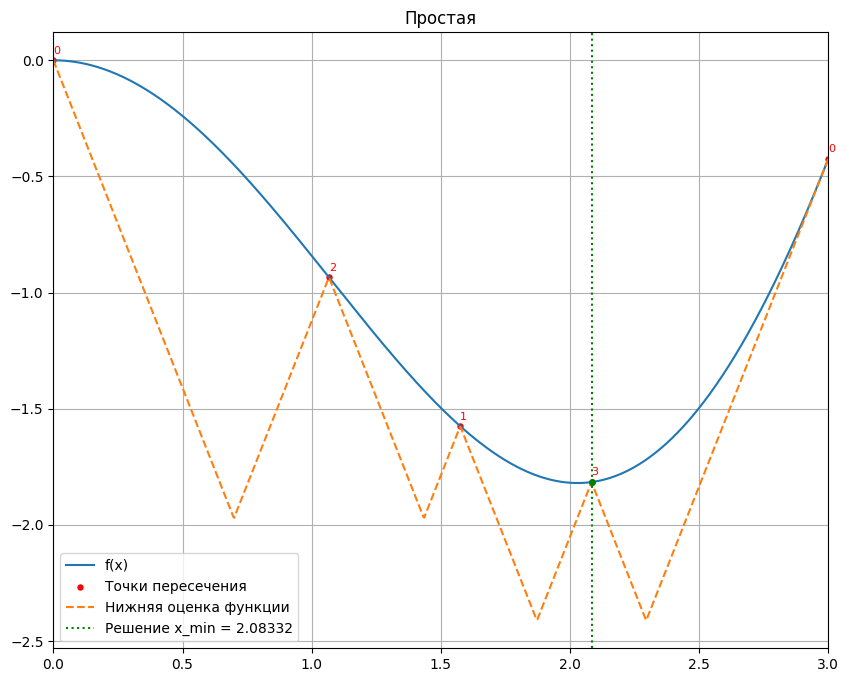


Пример: Функция Экли
Разобранное выражение:  -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2))) - np.exp(0.5 * (np.cos(2 * np.pi * x))) + np.e + 20
Используем оценку L = 6.24885
Результат:
  x_min = 0.0010983059738063846
  f_min = 1.072686423525795
Количество итераций: 20
Затраченное время (с): 0.0019996166229248047
Причина остановки: Достигнута точность: 0.00764073 <= 0.01 (f_best - g_min <= eps)


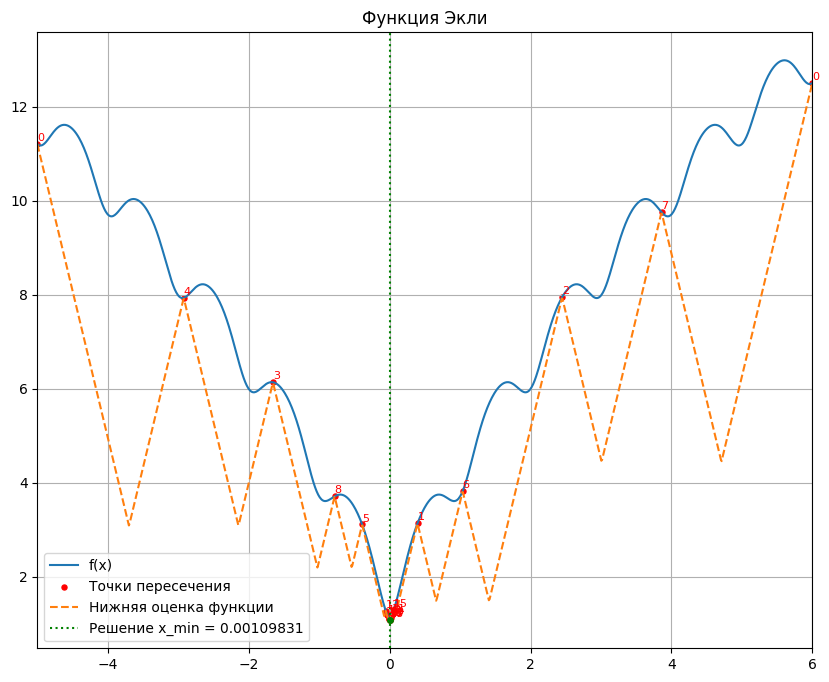


Пример: Функция Растригина (Много похожих локальных мимнимумов)
Разобранное выражение: 10 + x**2 - 10*np.cos(2*np.pi*x)
Используем оценку L = 71.0644
Результат:
  x_min = 0.0
  f_min = 0.0
Количество итераций: 148
Затраченное время (с): 0.022218942642211914
Причина остановки: Достигнута точность: 0.00997673 <= 0.01 (f_best - g_min <= eps)


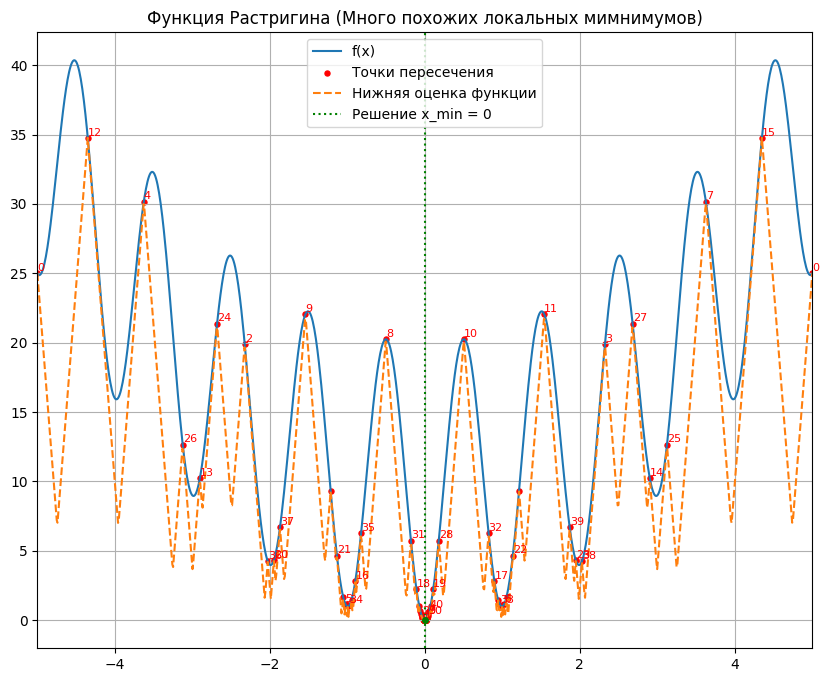

In [3]:

# Примеры запуска
from math import pi

examples = [
    {
        "name": "Простая",
        "expr": "-x * sin(x)",
        "a": 0, "b": 3, "eps": 1e-0
    },
    {
        "name": "Функция Экли",
        "expr": " -20 * exp(-0.2 * sqrt(0.5 * (x**2))) - exp(0.5 * (cos(2 * pi * x))) + np.e + 20",
        "a": -5, "b": 6, "eps": 1e-2
    },
    {
        "name": "Функция Растригина (Много похожих локальных мимнимумов)",
        "expr": "10 + x**2 - 10*cos(2*pi*x)",
        "a": -5, "b": 5, "eps": 1e-2
    }
]

for ex in examples:
    print('\n' + '='*60)
    print('Пример:', ex['name'])
    f, parsed = parse_function_string(ex['expr'])
    print('Разобранное выражение:', parsed)
    res = piyavskii_shubert(f, ex['a'], ex['b'], eps=ex['eps'], L=None, max_iter=500, L_est_points=400, verbose=True)
    print('Результат:')
    print('  x_min =', res['x_min'])
    print('  f_min =', res['f_min'])
    print('Количество итераций:', res['iterations'])
    print('Затраченное время (с):', res['time'])
    print('Причина остановки:', res['stop_reason'])
    # визуализация
    hist = res['history'][-1]
    plot_iteration(
        f, ex['a'], ex['b'],
        hist['xs'], hist['fs'], hist['itNumber'],
        res['L'],
        final_x=res['x_min'],
        title=ex['name']
    )



### Примечания и ограничения

- Оценка L через численную производную выполняется на сетке в `L_est_points` точках. Это **оценка** — для строгой корректности метода L **должен быть** истинной константой Липшица. Если вы знаете константу L точно, передайте её явно в `piyavskii_shubert(..., L=...)`.
- Мы **не** используем "перебор по мелкой сетке" для поиска минимума; сетка используется только для оценки L и визуализации. Сам поиск ведётся по точкам, найденным пересечениями конусов (ломаной).
- Для функций с бесконечными производными или разрывами метод не применим.
